In [1]:
%pip install numpy
%pip install matplotlib
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


    amaranth-yosys (>=0.10.*) ; extra == 'builtin-yosys'
                    ~~~~~~~^

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


    amaranth-yosys (>=0.10.*) ; extra == 'builtin-yosys'
                    ~~~~~~~^

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


    amaranth-yosys (>=0.10.*) ; extra == 'builtin-yosys'
                    ~~~~~~~^

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Gradient Descent

In this `.ipynb` we use gradient descent with the linear regression model. Gradient descent is used to 
produce a model withthe lowest loss. It is done iteratively with a given
dataset. For the loss the function we will use Mean Square Root.

## Mean Square Root Loss Function

- $\frac{1}{N} \sum{}^{}(y_{actual} - y_{pred})^2$

Where $y_{pred}$ represents:

- $y_{pred}=w_{1}x_{1}+b$

$w_{1}$ represents the weight, $x_{1}$ represents the input (feature value), and $b$ represents the bias.

## Gradients

For the gradients it's represented as:

- $\frac{J \delta}{\delta w} = \frac{-2}{N} \sum{}^{} x_i(y_{actual} - y_{pred})$

- $\frac{J \delta}{\delta b} = \frac{-2}{N} \sum{}^{} y_{actual} - y_{pred}$



Text(0.5, 0, 'Feature')

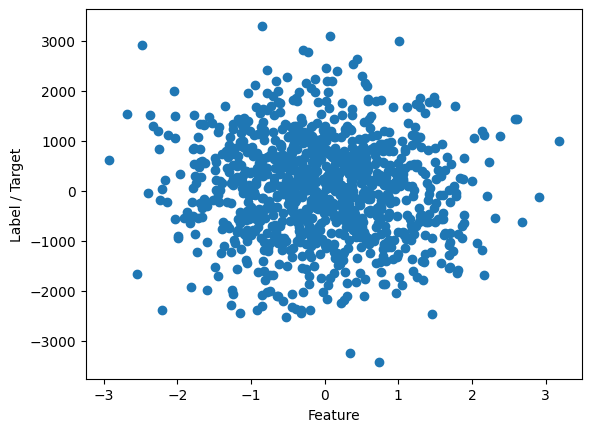

In [68]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.datasets import make_regression

# creating a random data set
X, y = make_regression(
    n_samples=1000,
    noise=1000,
    n_features=1
)

plt.scatter(X, y)
plt.ylabel("Label / Target")
plt.xlabel("Feature")


# Hyperparameters for Gradient Descent
---
## Full-batch
Full batch gradient descent inputs the whole dataset hence "full-batch" for each epoch.
Though this is not convention since in production we would want efficent training.
Datasets can go from thousands to millions of features, thus making models not properly being scaled well for this.

## Stochastic
Stochastic gradient descent inputs a random single example in the dataset.
Making so that each example is ran at least once per epoch. Thus this makes a batch size of one.
So if you have 100 examples, in total you would run 100 per epoch.

## Mini-batch
Mini-batch involves a set of batches in $N$ number of examples in a data set where the batch is less than $N$.
Similar to stochastic instead of a single example in a batch per iteration we have a set of examples in a batch per iteration. 

In [69]:
class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'  # Resets the color/style
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

class Settings:
    def __init__(self, epochs=1000, learning_rate=0.1, monitor_iter = 10):
        self.monitor_iter = monitor_iter
        self.learning_rate = learning_rate
        self.epochs = epochs

        self.cost_per_iteration = []
        self.weights = []
        self.biases = []

        self.starting_weight = 0
        self.weight = 0
        self.bias = 0
        self.cost = 0

# FULL BATCH
class FullBatch(Settings):
    def __init__(self,epochs=1000, learning_rate=0.1):
        super().__init__(epochs, learning_rate)

    def full_batch(self, X, y_actual):
        N = len(X)

        for i in range(self.epochs):
            if i == 2:
                self.starting_weight = self.weight
          
            # since its full batch we use the entire batch `X`
            y_pred = self.weight * X + self.bias

            # derivative of MSE with respect to weight and bias
            dweight = (-2/N) * np.sum(X * (y_actual - y_pred))
            dbias = (-2/N) * np.sum((y_actual - y_pred))

            # "new weight" "old weight"  "learning rate"  "weight slope"
            self.weight = self.weight - self.learning_rate * dweight
            self.bias   = self.bias   - self.learning_rate * dbias

            self.cost = (1/N) * np.sum((y_actual - y_pred) ** 2)
            self.cost_per_iteration.append(self.cost)

            self.weights.append(self.weight)
            self.biases.append(self.bias)

            if i % self.monitor_iter == 0:
                print(f"[FL-B] Iteration {i} - Weight: {self.weight} Bias {self.bias} Cost {self.cost}")

        print("[FL-B] Gradient Descent Finished.")
        print(f"{bcolors.OKGREEN}[FL-B] Final - Weight: {self.weight} Bias {self.bias} Cost {self.cost}{bcolors.ENDC}")
        return

# STOCHASTIC
class Stochastic(Settings):
    def __init__(self,epochs=1000, learning_rate=0.1):
        super().__init__(epochs, learning_rate)
    
    def stochastic_epoch(self, X, y_actual):
        N = len(X)

        # "shuffle"
        shuffled_indices = np.random.permutation(N)

        # use shuffled indices and look in each example once
        for random_idx in shuffled_indices:
            X_rand = X[random_idx]
            y_actual_rand = y_actual[random_idx]
          
            y_pred = self.weight * X_rand + self.bias

            # derivative of MSE with respect to weight and bias
            dweight = -2 * np.sum(X_rand * (y_actual_rand - y_pred))
            dbias = -2 * np.sum((y_actual_rand - y_pred))

            # "new weight" "old weight"  "learning rate"   "weight slope"
            self.weight = self.weight - self.learning_rate * dweight
            self.bias   = self.bias   - self.learning_rate * dbias

        # calculate predection at the end of epoch
        y_full_pred = self.weight * X + self.bias
        self.cost = (1/N) * np.sum((y_actual - y_full_pred) ** 2)
        self.cost_per_iteration.append(self.cost)

    def stochastic(self, X, y_actual):
        N = len(X)

        for i in range(self.epochs):
            if i == 2:
                self.starting_weight = self.weight
          
            self.stochastic_epoch(X, y_actual)
            self.weights.append(self.weight)
            self.biases.append(self.bias)

            if i % self.monitor_iter == 0:
                print(f"[SGD] Iteration {i} - Weight: {self.weight} Bias {self.bias} Cost {self.cost}")

        print("[SGD] Gradient Descent Finished.")
        print(f"{bcolors.OKGREEN}[SGD] Final - Weight: {self.weight} Bias {self.bias} Cost {self.cost}{bcolors.ENDC}")
        return

# MINI BATCH
class MiniBatch(Settings):
    def __init__(self, epochs=1000, learning_rate=0.1, batch_size=None):
        super().__init__(epochs, learning_rate)
        self.batch_size = batch_size

    def y_pred(self, X):
        return (X * self.weight) + self.bias
    
    def mini_batch(self, X, y_actual):
        for i in range(self.epochs):
            if i == 2:
                self.starting_weight = self.weight
            self.mini_batch_epoch(X, y_actual)
            self.weights.append(self.weight)
            self.biases.append(self.bias)

            if i % self.monitor_iter == 0:
                print(f"[MN-B] Iteration {i} - Weight: {self.weight} Bias {self.bias} Cost {self.cost}")

        print("[MN-B] Gradient Descent Finished.")
        print(f"{bcolors.OKGREEN}[MN-B] Final - Weight: {self.weight} Bias {self.bias} Cost {self.cost}{bcolors.ENDC}")
        return

    def mini_batch_epoch(self, X, y_actual):
        N = len(X)

        for start in range(0,N,self.batch_size):
            # start : batch_size so that it goes through all 
            # the data in batches
            X_batch = X[start:start + self.batch_size]
            y_batch = y_actual[start:start + self.batch_size]
            N_batch = len(X_batch)

            # calculating gradients
            dweight = (-2/N_batch) * np.sum(X_batch * (y_batch - self.y_pred(X_batch)))
            dbias   = (-2/N_batch) * np.sum((y_batch - self.y_pred(X_batch)))

            # improvement
            self.weight -= (self.learning_rate * dweight)
            self.bias   -= (self.learning_rate * dbias)
        
        self.cost = (1/N) * np.sum((y_actual - self.y_pred(X)) ** 2)
        self.cost_per_iteration.append(self.cost)
        return


# Simiulation Results

We compare data between:
- Full-batch
- Stochastic
- Mini-batch
Producing graphs and data.

In [ ]:
# for timing
import tracemalloc


epochs = 100
Settings(monitor_iter=epochs/10)

full_batch = FullBatch(epochs=int(epochs), learning_rate=0.01)
stochastic = Stochastic(epochs=int(epochs), learning_rate=0.01)
minibatch  = MiniBatch(epochs=int(epochs), learning_rate=0.01, batch_size=200)

X = X.flatten()

# Full-Batch
tracemalloc.start()
start = time.time()
full_batch.full_batch(X, y)
fb_time = time.time() - start
fb_mem = tracemalloc.get_traced_memory()[1]
tracemalloc.stop()

# Stochastic
tracemalloc.start()
start = time.time()
stochastic.stochastic(X, y)
st_time = time.time() - start
st_mem = tracemalloc.get_traced_memory()[1]
tracemalloc.stop()

# Mini-Batch
tracemalloc.start()
start = time.time()
minibatch.mini_batch(X, y)
mb_time = time.time() - start
mb_mem = tracemalloc.get_traced_memory()[1]
tracemalloc.stop()

print(f"{'Algorithm':<12} {'Time (s)':<12} {'Peak Memory'}")
print(f"{'-'*36}")
print(f"{'Full-Batch':<12} {fb_time:<12.4f} {fb_mem / 1024:.2f} KB")
print(f"{'Stochastic':<12} {st_time:<12.4f} {st_mem / 1024:.2f} KB")
print(f"{'Mini-Batch':<12} {mb_time:<12.4f} {mb_mem / 1024:.2f} KB")

[FL-B] Iteration 0 - Weight: -1.0944318915204871 Bias 0.619576377023752 Cost 1021364.9316595652
[FL-B] Iteration 10 - Weight: -10.967726978624869 Bias 6.121659074749818 Cost 1020044.7837534905
[FL-B] Iteration 20 - Weight: -19.133823415500046 Bias 10.53778068273117 Cost 1019154.2244664587
[FL-B] Iteration 30 - Weight: -25.889000297728206 Bias 14.080331280354203 Cost 1018553.0738741868
[FL-B] Iteration 40 - Weight: -31.477925322280026 Bias 16.920465640623156 Cost 1018147.0163278615
[FL-B] Iteration 50 - Weight: -36.10267961389701 Bias 19.196061321072815 Cost 1017872.5563037817
[FL-B] Iteration 60 - Weight: -39.93019842701227 Bias 21.018148456999036 Cost 1017686.9208995178
[FL-B] Iteration 70 - Weight: -43.09840684450531 Bias 22.476103553602808 Cost 1017561.2787510061
[FL-B] Iteration 80 - Weight: -45.72128022796485 Bias 23.641843862556968 Cost 1017476.1835640584
[FL-B] Iteration 90 - Weight: -47.893018571104314 Bias 24.573213804894213 Cost 1017418.5106879208
[FL-B] Gradient Descent Fini

Text(0.5, 1.0, 'Linear Regression: Mini-Batch')

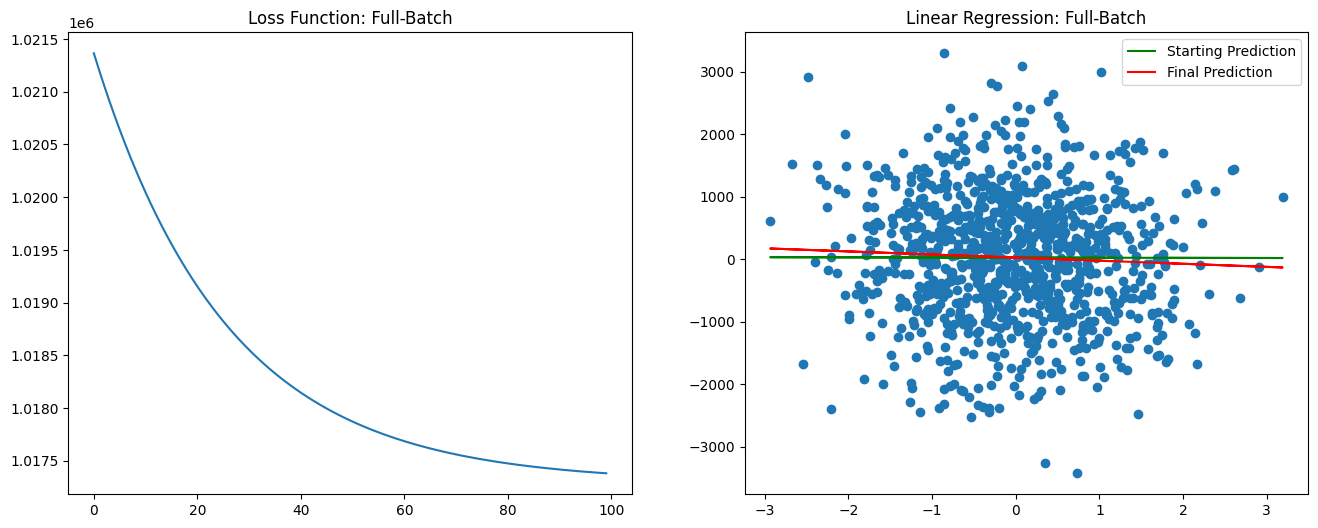

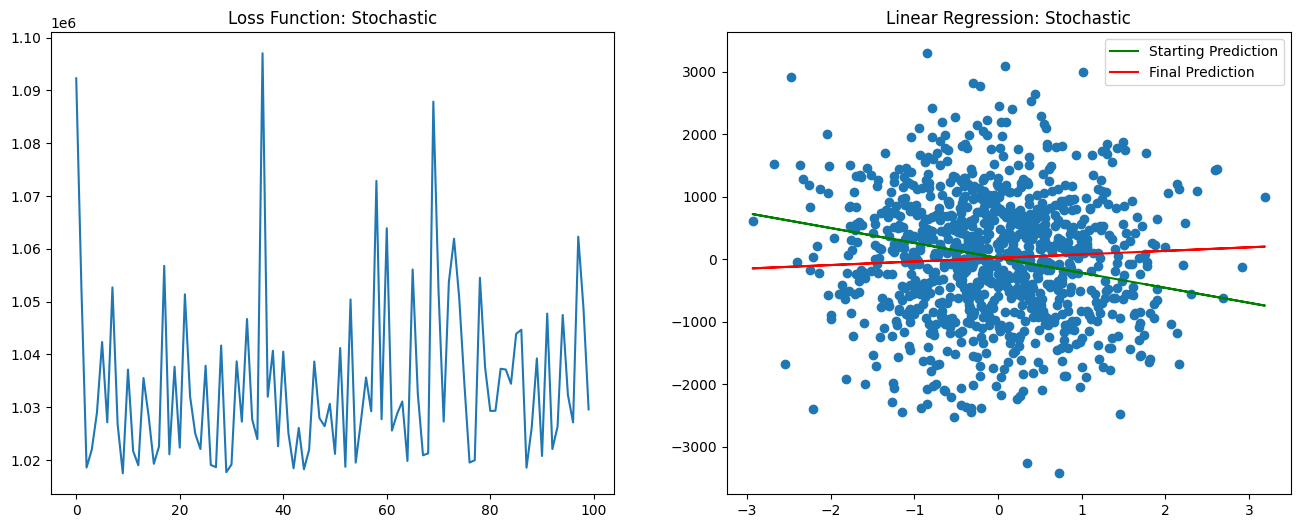

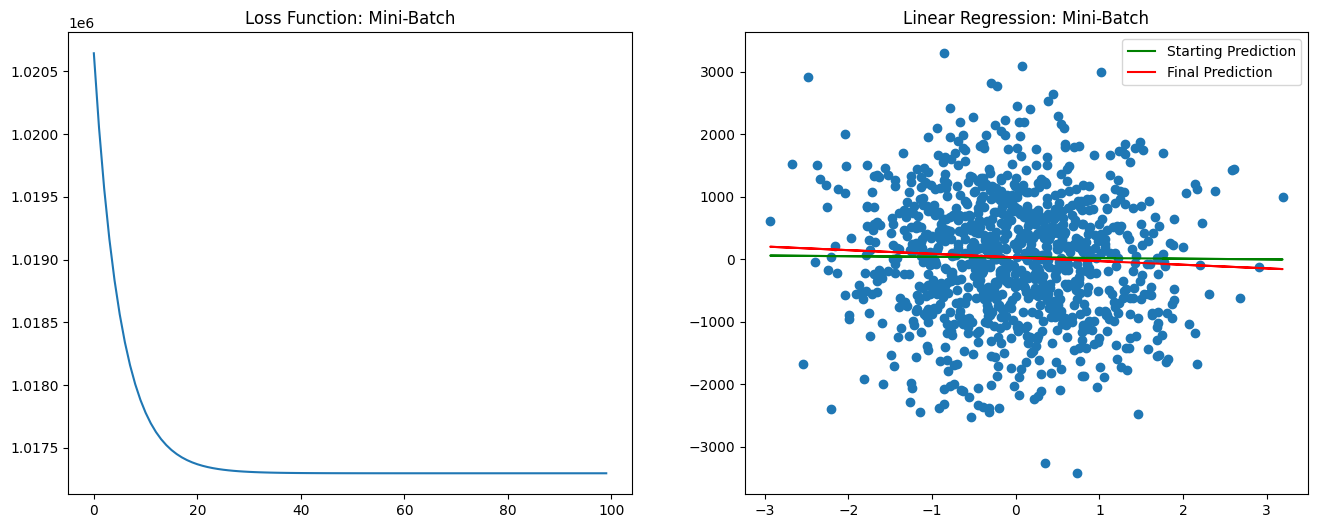

In [71]:

# CREATE FIGURES

fig1, (ax1,ax2) = plt.subplots(1, 2,figsize=(16,6))
fig2, (ax3,ax4) = plt.subplots(1, 2,figsize=(16,6))
fig3, (ax5,ax6) = plt.subplots(1, 2,figsize=(16,6))

### FULL-BATCH

ax1.plot(range(epochs), full_batch.cost_per_iteration)
ax1.set_title("Loss Function: Full-Batch")

ax2.scatter(X, y)
y_starting_pred = full_batch.starting_weight * X + full_batch.bias
y_pred_final = full_batch.weight * X + full_batch.bias
ax2.plot(X, y_starting_pred, color="green",label="Starting Prediction")
ax2.plot(X, y_pred_final, color="red", label="Final Prediction")
ax2.legend()
ax2.set_title("Linear Regression: Full-Batch")

### STOCHASTIC

ax3.plot(range(epochs), stochastic.cost_per_iteration)
ax3.set_title("Loss Function: Stochastic")

ax4.scatter(X, y)
y_starting_pred = stochastic.starting_weight * X + stochastic.bias
y_pred_final = stochastic.weight * X + stochastic.bias
ax4.plot(X, y_starting_pred, color="green",label="Starting Prediction")
ax4.plot(X, y_pred_final, color="red", label="Final Prediction")
ax4.legend()
ax4.set_title("Linear Regression: Stochastic")


### MINI-BATCH

ax5.plot(range(epochs), minibatch.cost_per_iteration)
ax5.set_title("Loss Function: Mini-Batch")

ax6.scatter(X, y)
y_starting_pred = minibatch.starting_weight * X + minibatch.bias
y_pred_final = minibatch.weight * X + minibatch.bias
ax6.plot(X, y_starting_pred, color="green",label="Starting Prediction")
ax6.plot(X, y_pred_final, color="red", label="Final Prediction")
ax6.legend()
ax6.set_title("Linear Regression: Mini-Batch")



`zeros_like` output:

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
`W_mesh.shape[0 and 1]` output:

100
100


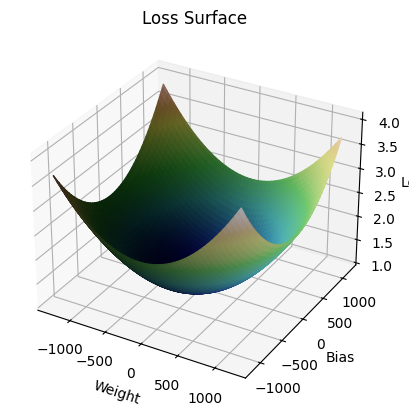

In [ ]:

from matplotlib import cm
from matplotlib.colors import LightSource

# creates even spaces
W = np.linspace(min(stochastic.weights)-1000,max(stochastic.weights)+1000, 100)
B = np.linspace(min(stochastic.biases)-1000,max(stochastic.biases)+1000, 100)

# we create a mesh for the surface
# use mesh to calculate Z plane
W_mesh, B_mesh = np.meshgrid(W, B)

# create zeros matrix
Z = np.zeros_like(W_mesh)
print("`zeros_like` output:\n")
print(Z)

# shape returns shape of array
# we access the length in order
# to build Z points
print("`W_mesh.shape[0 and 1]` output:\n")
print(W_mesh.shape[0])
print(W_mesh.shape[1])

for i in range(W_mesh.shape[0]):
    for j in range(W_mesh.shape[1]):
        Y_pred = W_mesh[i, j] * X + B_mesh[i, j]
        Z[i, j] = (1/len(X)) * np.sum((y - Y_pred) ** 2)

fig = plt.figure()
ls = LightSource(270, 45)
rgb = ls.shade(Z, cmap=cm.gist_earth, blend_mode="soft")
ax = fig.add_subplot(projection='3d')
ax.plot_surface(W_mesh, B_mesh, Z, facecolors=rgb)
ax.set_xlabel("Weight")
ax.set_ylabel("Bias")
ax.set_zlabel("Loss")
ax.set_title("Loss Surface")
plt.show()

